---
title: Joint probability inference
---


In [2]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

# set_log_level('DEBUG')

## Discrete feature joint probability

If you have access to marginal features like counts of mutations shared by your samples (singletons, doubletons etc.), You can compute the joint probability of such events exactly.

## Coalescent

In [3]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

Step one is to construct the model graph.

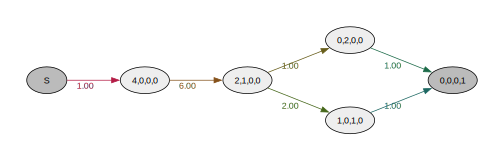

In [4]:
graph = Graph(coalescent_1param)
graph.plot()

From the model graph we can now create an augmented discrete graph that allow us to compute joint probabilities. This graph is generated for this purpose only and does not otherwise represent the original model. The trick is to track all combinations of events. Each combination is represented by a state with the absorbing one as its only child making each of them the last state in a path through the graph. The probability of passing through one such state thus represents a joint probability. Because we cannot model infinitely many combinations of discrete events, we cap the number of allowed events and route all additional events to an infinite loop not contributing to any joint probability thus defining the distributions deficit.

In [ ]:
mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(indexer, tot_reward_limit = 2, mutation_rate = mutation_rate)
joint_prob_graph.vertices_length()

: 

Note that the edges now have, not one, but two coefficients. The extra one holds a value scaling the mutation rate.

In [ ]:
joint_prob_graph.param_length()

Update edge weights to make the model reflect our true parameter values:

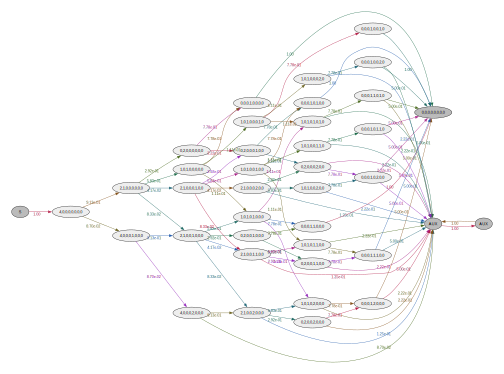

In [13]:
true_theta = [7, mutation_rate]
joint_prob_graph.update_weights(true_theta)
joint_prob_graph.plot(nodesep=0.3)

Compute the joint probabilities:

In [14]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,0.621377
18,0,1,0,0,0.071919
20,1,0,0,0,0.151842
23,0,0,1,0,0.046028
30,0,2,0,0,0.013225
31,2,0,0,0,0.026469
32,1,0,1,0,0.018067
33,0,0,2,0,0.005114
34,1,1,0,0,0.016322


Deficit:

In [15]:
(1 - joint_prob_table['prob'].sum()).item()

0.02771995193202048

### Test data

For testing and demonstration purposes, we can sample observations from the model.

In [16]:
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    joint_prob_graph.update_weights(theta) 
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

In [17]:
true_theta = [7, mutation_rate] # coalescent rate and mutation rate
observations = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=1000)
observations[:5]

[[0, 0, 0, 0], [2, 0, 0, 0], [1, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

For real data, make sure to only to include observations that are possible under the model:

```python
modelled_obs = joint.loc[sample, joint.columns[:-1]].to_numpy().tolist()
allowed_observations = set(tuple(x) for x in modelled_obs)
observations = [o for o in observations if tuple(o) in allowed_observations]
observations = np.array(observations)
observations
```

Convert to the corresponding indices in the joint graph:

In [ ]:
#set_log_level('DEBUG')

svgd = joint_prob_graph.svgd(
    observations, 
    fixed=[(1, mutation_rate)],  # Fix theta[1] (mutation) at actual mutation_rate value
    n_iterations=200,
    prior=GaussPrior(ci=[1, 5]),
    # optimizer=Adamelia(learning_rate=0.2),
    learning_rate = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
    # regularization=ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0),
    )

In [ ]:
svgd.summary(ci_method='hpd', ci_level=0.95)

In [ ]:
svgd.plot_ci(ci_method='hpd')

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_trace()

## ARG

In [31]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level,
    optax_adam
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

#set_log_level('DEBUG')

In [ ]:
# create state space for two-locus model
nr_samples = 3
indexer = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples),
        Property('loc2', min_value=0, max_value=nr_samples)
    ]
)

# initial state with all lineages having one descendant at both loci
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg_2param(state, indexer=None):

    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_loc1 = props_i.loc1 + props_j.loc1
            des_loc2 = props_i.loc2 + props_j.loc2
            if des_loc1 <= nr_samples and des_loc2 <= nr_samples:
                child[indexer.descendants.props_to_index(loc1=des_loc1, loc2=des_loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0 and props_i.loc1 > 0 and props_i.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.descendants.props_to_index(loc1=0, loc2=props_i.loc2)] += 1
            child[indexer.descendants.props_to_index(loc1=props_i.loc1, loc2=0)] += 1
            transitions.append([child, [0, state[i]]])
            # transitions.append([child, [0, 1]])

    return transitions

In [ ]:
graph = Graph(two_locus_arg_2param, indexer=indexer, 
            #   cache_graph=True, 
            #   cache_trace=True
            )
graph.vertices_length()

In [ ]:
graph.plot(nodesep=0.5)

In [ ]:
mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(indexer,
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )

In [ ]:
true_theta = [10, 1, mutation_rate] # coalescent, recombination, and mutation rate
observations = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=1000)
observations[:5]

In [ ]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table.head()

In [ ]:
ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0).plot(100) 

In [ ]:
%%monitor

svgd = joint_prob_graph.svgd(
    observed_data=observations, 
    fixed=[(2, mutation_rate)],
    n_iterations=100,
    n_particles=200,
    prior=[
        GaussPrior(ci=[5, 25]),
        GaussPrior(ci=[0, 3]),
        None
    ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
    )
svgd.summary()

In [ ]:
svgd.plot_ci(ci_method='hpd')

In [ ]:
svgd.plot_convergence() ;

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.map_estimate_from_particles()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_hdr(hexgrid=False) ;

In [ ]:
svgd.plot_pairwise(true_theta=true_theta) ;

In [ ]:
#svgd.animate_pairwise(true_theta=true_theta)

## Example data

Simulation of two-island model:

In [ ]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

# # isolation with migration (IM) model:
# demography = msprime.Demography()
# demography.add_population(name="pop1", initial_size=pop1_size)
# demography.add_population(name="pop2", initial_size=pop2_size)
# demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
# demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
# demography.add_population(name="ancestral", initial_size=anc_pop_size)
# demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
# ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
#                           demography=demography, recombination_rate=rec_rate, 
#                           sequence_length=seq_length, random_seed=12)
# ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
# df = derived_counts(ts, rec_rate)
# df.to_csv("IM_model_derived_counts.csv", index=False)

Get pairs of variants in the specified distance range.

In [ ]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

We allow multiple SNPs from the same tree, but each SNP can only be part of a single pair. Remove pairs that share a position with another pair:

In [ ]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

Plot position differences for pairs of variants:

In [ ]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [ ]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [ ]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)

Can you make a model and find the true parameters?

## Baboon ARG inference

In [ ]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

# set_log_level('DEBUG')

Load data 

In [ ]:
ds = sg.load_dataset(
    "/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz"
)

print("Antal samples:", len(ds['sample_id']))
ds['sample_id'].values[:10]

Vælg samples 

In [ ]:
keep = ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203']

mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)

nr_samples = len(keep) * 2  # diploid → haplotyper
print("Nr haploid samples:", nr_samples)

Derived allele counts 

In [ ]:
variant_allele_counts = sg.count_variant_alleles(ds_sub)
ac = variant_allele_counts["variant_allele_count"].values

df = pd.DataFrame({
    "position": ds_sub["variant_position"].values,
    "count": ac[:, 1],
})

df = df[df["count"] <= nr_samples]

df.head()

SNP pairs funktion

In [ ]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

Lav SNP pairs

In [ ]:
distance = 5000
tolerance = 500

pairs_idx = pairs_in_range(
    df["position"].values,
    distance - tolerance,
    distance + tolerance
)

records = []
for i, j in pairs_idx:
    records.append((df.iloc[i]["count"], df.iloc[j]["count"]))

pairs_df = pd.DataFrame(records, columns=["count1", "count2"])

# Begræns størrelse (meget vigtigt!)
pairs_df = pairs_df.sample(2000, random_state=42)

print("Antal pairs:", len(pairs_df))
pairs_df.head()

Observations

In [ ]:
n = len(pairs_df)
observations = np.zeros((n, nr_samples + 1), dtype=int)

for i, (c1, c2) in enumerate(pairs_df.values):
    observations[i, int(c1)] = 1
    observations[i, int(c2)] = 1

observations[:5]

Model setup

In [ ]:
nr_samples_model = nr_samples

indexer = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples_model),
        Property('loc2', min_value=0, max_value=nr_samples_model)
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples_model

ARG transitions

In [ ]:
@with_ipv(initial)
def two_locus_arg_2param(state, indexer=None):

    transitions = []
    if state.sum() <= 1:
        return transitions

    for i in range(indexer.state_length):
        if state[i] == 0:
            continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0:
                continue
            props_j = indexer.descendants.index_to_props(j)

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue

            child = state.copy()
            child[i] -= 1
            child[j] -= 1

            des_loc1 = props_i.loc1 + props_j.loc1
            des_loc2 = props_i.loc2 + props_j.loc2

            if des_loc1 <= nr_samples_model and des_loc2 <= nr_samples_model:
                child[indexer.descendants.props_to_index(loc1=des_loc1, loc2=des_loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        # recombination
        if state[i] > 0 and props_i.loc1 > 0 and props_i.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.descendants.props_to_index(loc1=0, loc2=props_i.loc2)] += 1
            child[indexer.descendants.props_to_index(loc1=props_i.loc1, loc2=0)] += 1
            transitions.append([child, [0, state[i]]])

    return transitions

Graph + joint probability

In [ ]:
graph = Graph(two_locus_arg_2param, indexer=indexer)

mutation_rate = 1

joint_prob_graph = graph.joint_prob_graph(
    indexer,
    tot_reward_limit=2,
    mutation_rate=mutation_rate
)

Inference

In [ ]:
svgd = joint_prob_graph.svgd(
    observed_data=observations,
    fixed=[(2, mutation_rate)],
    n_iterations=100,
    n_particles=100,
    prior=[
        GaussPrior(ci=[5, 50]),
        GaussPrior(ci=[0, 5]),
        None
    ],
    learning_rate=ExpStepSize(
        first_step=0.1,
        last_step=0.01,
        tau=50.0
    ),
)

Resultater 

In [ ]:
svgd.summary()

In [ ]:
svgd.plot_ci()

In [ ]:
svgd.plot_trace()